In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [48]:
data_path = '/content/drive/My Drive/Copy of in-vehicle-coupon-recommendation.csv'
IVC = pd.read_csv(data_path)


**Data Overview**

In [49]:
IVC.info()
IVC.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           12684 non-null  object
 1   passanger             12684 non-null  object
 2   weather               12684 non-null  object
 3   temperature           12684 non-null  int64 
 4   time                  12684 non-null  object
 5   coupon                12684 non-null  object
 6   expiration            12684 non-null  object
 7   gender                12684 non-null  object
 8   age                   12684 non-null  object
 9   maritalStatus         12684 non-null  object
 10  has_children          12684 non-null  int64 
 11  education             12684 non-null  object
 12  occupation            12684 non-null  object
 13  income                12684 non-null  object
 14  car                   108 non-null    object
 15  Bar                   12577 non-null

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


**Missing values check**

In [50]:
IVC.isnull().sum()

,0
destination,0
passanger,0
weather,0
temperature,0
time,0
coupon,0
expiration,0
gender,0
age,0
maritalStatus,0


**Data Cleaning**

Before performing analysis, we checked for missing values in the dataset.
Rows containing missing values were removed to ensure clean and consistent analysis.


The dataset was checked for missing values. The column "car" contained a large number of missing values and was removed. Rows with remaining missing values were dropped to ensure clean data for analysis.

In [51]:
IVC['car'].isna().mean()

np.float64(0.9914853358561968)

In [52]:
# Remove column with too many missing values
IVC = IVC.drop(columns=['car'])

In [53]:
# Remove rows with remaining missing values
IVC = IVC.dropna()

In [54]:
IVC.isna().sum()

,0
destination,0
passanger,0
weather,0
temperature,0
time,0
coupon,0
expiration,0
gender,0
age,0
maritalStatus,0


**Exploratory Data Analysis**

weather distribution

/tmp/ipykernel_351/3417698211.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=IVC, x='weather', palette='viridis')


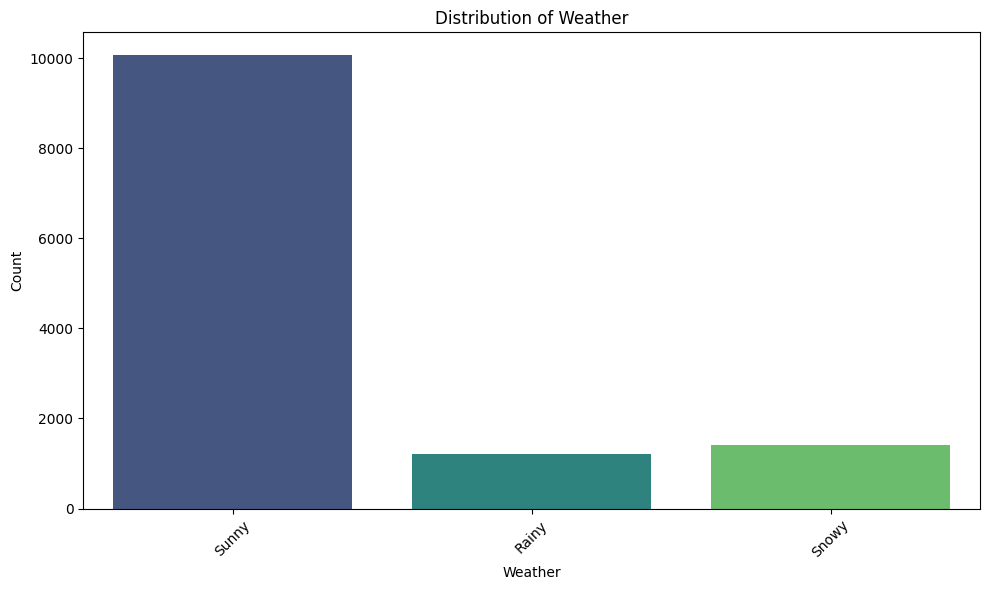

In [7]:
plt.figure(figsize=(10, 6))
sns.countplot(data=IVC, x='weather', palette='viridis')
plt.title('Distribution of Weather')
plt.xlabel('Weather')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

coupon distribution

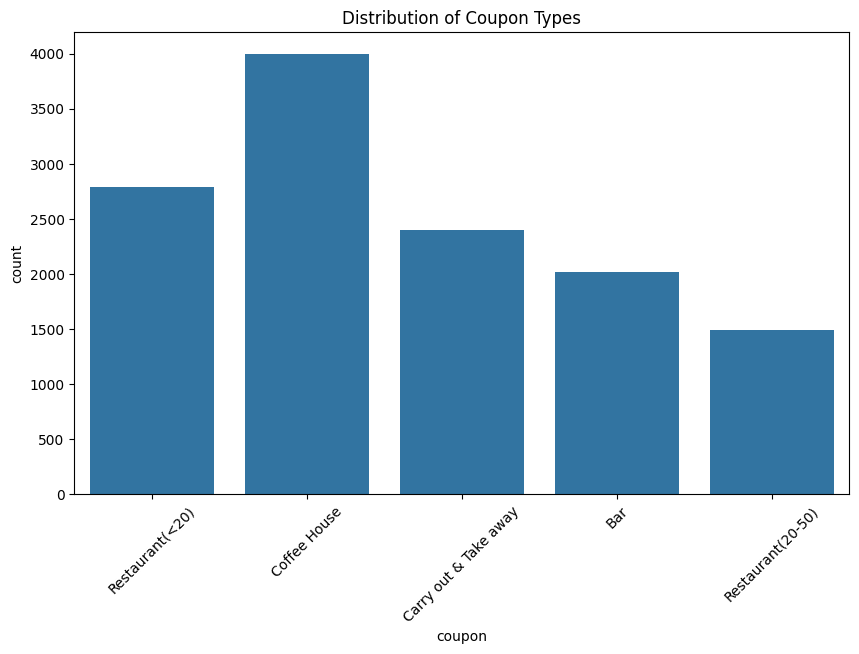

In [11]:
plt.figure(figsize=(10,6))
sns.countplot(data=IVC, x='coupon')
plt.title('Distribution of Coupon Types')
plt.xticks(rotation=45)
plt.show()

acceptance distribution

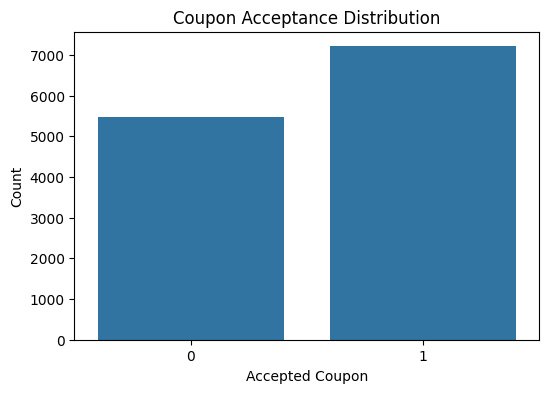

In [10]:
plt.figure(figsize=(6,4))
sns.countplot(data=IVC, x='Y')
plt.title('Coupon Acceptance Distribution')
plt.xlabel('Accepted Coupon')
plt.ylabel('Count')
plt.show()

weather vs acceptance

<Axes: xlabel='weather', ylabel='count'>

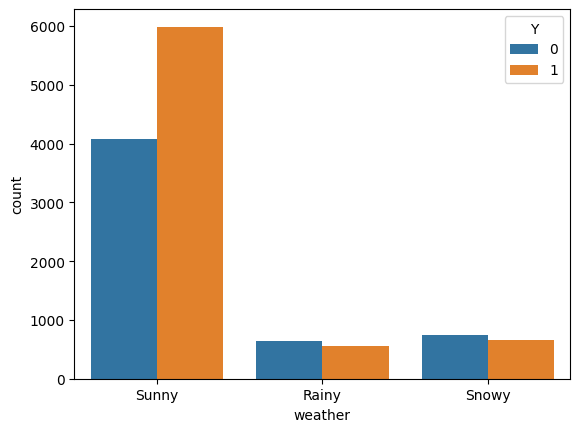

In [8]:
sns.countplot(data=IVC, x='weather', hue='Y')
plt.title('Distribution of coupons under different weather conditions')

time vs acceptance

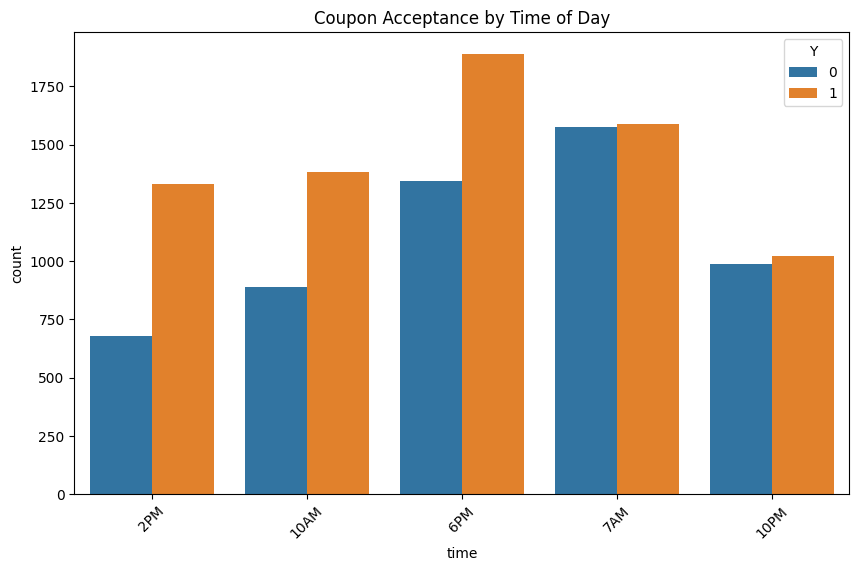

In [12]:
plt.figure(figsize=(10,6))
sns.countplot(data=IVC, x='time', hue='Y')
plt.title('Coupon Acceptance by Time of Day')
plt.xticks(rotation=45)
plt.show()

temperature distribution

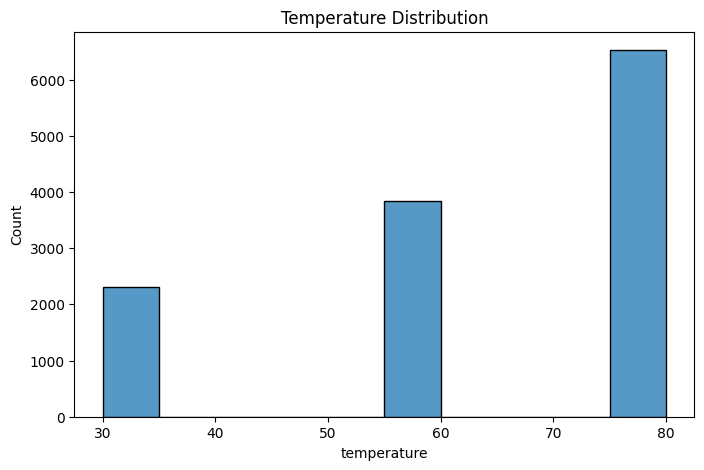

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(IVC['temperature'], bins=10)
plt.title('Temperature Distribution')
plt.show()

Insights:

1. Coupon acceptance varies depending on weather. people are more likly to accept coupons on Sunny days.
2. 6pm has higher coupon acceptance rates.
3. Different coupon types appear with different frequencies in the dataset.

**Coupon Acceptance Rate**

This shows the overall proportion of drivers who accepted the coupon.



In [56]:
accept_rate = IVC['Y'].mean()
print("Coupon acceptance rate:", accept_rate)

Coupon acceptance rate: 0.5693352098683666


**Acceptance Rates for Different Coupon Types**

In [57]:
IVC.groupby('coupon')['Y'].mean().sort_values(ascending=False)

,Y
coupon,
Carry out & Take away,0.737719
Restaurant(<20),0.709009
Coffee House,0.496331
Restaurant(20-50),0.446013
Bar,0.411918


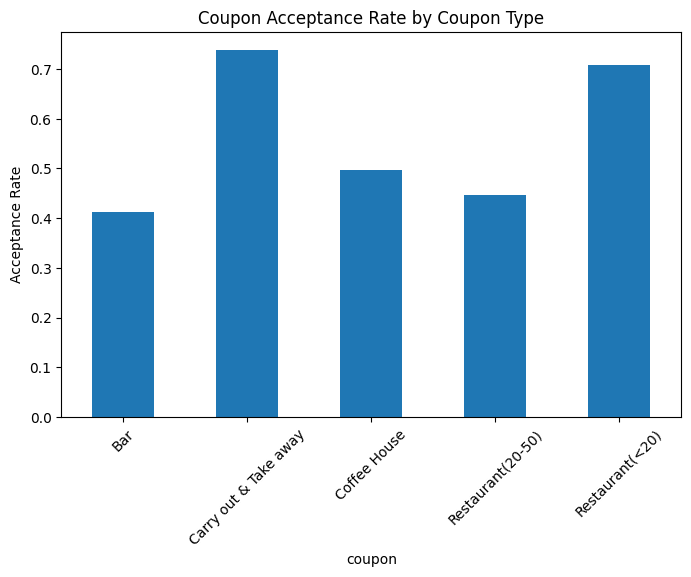

In [58]:
plt.figure(figsize=(8,5))
IVC.groupby('coupon')['Y'].mean().plot(kind='bar')
plt.title("Coupon Acceptance Rate by Coupon Type")
plt.ylabel("Acceptance Rate")
plt.xticks(rotation=45)
plt.show()

Coupon types of Carry out & Take away and Restaurant(<20) have higher acceptance rates than others.

**Weather's Impact on Coupon Acceptance**

This shows whether weather conditions influence coupon acceptance.

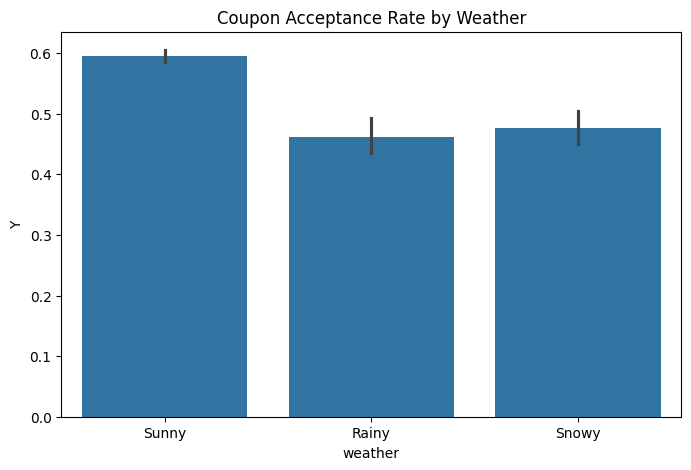

In [59]:
plt.figure(figsize=(8,5))
sns.barplot(data=IVC, x='weather', y='Y')
plt.title("Coupon Acceptance Rate by Weather")
plt.show()

**Time's Impact on Acceptance Rate**

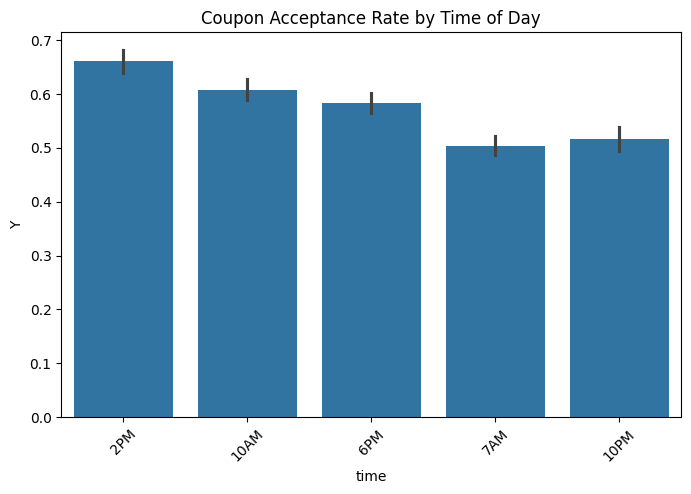

In [60]:
plt.figure(figsize=(8,5))
sns.barplot(data=IVC, x='time', y='Y')
plt.title("Coupon Acceptance Rate by Time of Day")
plt.xticks(rotation=45)
plt.show()

The coupon acceptance rate is higher at noon.

**Correlation heatmap**

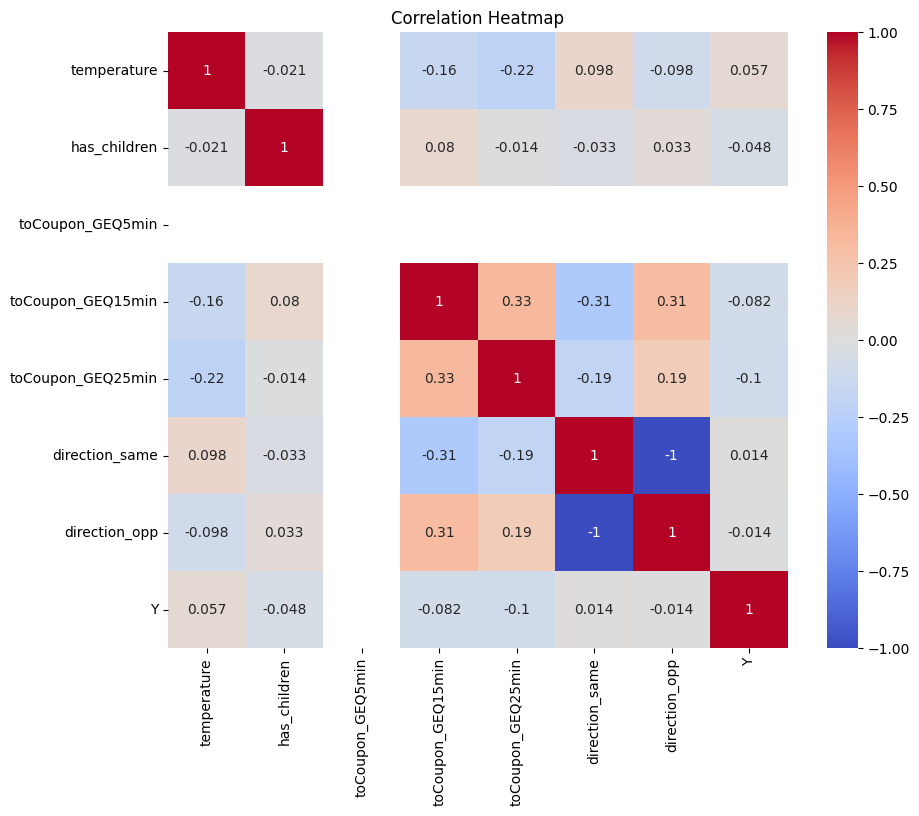

In [62]:
plt.figure(figsize=(10,8))
sns.heatmap(IVC.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

Key Insights

1. Coffee House coupons have the highest acceptance rate.
2. Drivers are more likely to accept coupons in sunny weather.
3. Acceptance rates vary depending on the time of day.